In [1]:
from pathlib import Path

In [2]:
BASE_DIR = Path.cwd()
print(BASE_DIR)

/home/evgeniy/Документы/GitHub/YandexNN/sprint_4


# Обработка текстов

## Токенизация

In [19]:
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

### is_digit, like_emails, like_utl in spicy

In [6]:
text = "123: hey ds_expert@w.com , check findme.com"

# загрузите модель для английского корпуса из spacy, models/en_core_web_sm
nlp = spacy.load("en_core_web_sm")

# преобразуйте текст во внутренний формат spacy
doc = nlp(text[:60])
tokens = [token.text for token in doc]

# проверьте, является ли токен числом, имейлом, ссылкой
digits = [token.is_digit for token in doc]
emails = [token.like_email for token in doc]
urls = [token.like_url for token in doc]

print("токены:", tokens)
print("числа:", digits)
print("имейлы:", emails)
print("ссылки:", urls)

токены: ['123', ':', 'hey', 'ds_expert@w.com', ',', 'check', 'findme.com']
числа: [True, False, False, False, False, False, False]
имейлы: [False, False, False, True, False, False, False]
ссылки: [False, False, False, False, False, False, True]


### sklearn with TF-IDF, stop-words

In [20]:
nltk.download('stopwords') 

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/evgeniy/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [23]:
file_path = BASE_DIR / "data" / "study_notebook" / "tiny_shakespear.txt"
text = file_path.read_text(encoding="utf-8")

stop_words = stopwords.words('english')

step = 100000
docs = [text[i:i+step] for i in range(0, len(text), step)]

tf_idf = TfidfVectorizer(stop_words=stop_words, max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tf_idf_matrix = tf_idf.fit_transform(docs)

  
print("N_documents x Vocabular_size:", tf_idf_matrix.shape)
print(tf_idf.get_feature_names_out()[:5])
print(tf_idf_matrix[0, :5].todense())

N_documents x Vocabular_size: (12, 10000)
['abandon' 'abate' 'abhor' 'abhorr' 'abhorred']
[[0.         0.         0.00361464 0.00259877 0.        ]]


## Лематизация

In [26]:
import pymorphy3

from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
import nltk

In [28]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/evgeniy/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [29]:
text = "Дети играли в снежки и пришли домой мокрые, но довольные"

# Инициализируем стеммер и выполняем токенизацию
stemmer = SnowballStemmer("russian")
tokens = word_tokenize(text, language="russian")

stems = [stemmer.stem(token) for token in tokens]
print("Стемминг (nltk):", stems)

morph = pymorphy3.MorphAnalyzer()

# Создаём список из лемм
lemms_pm = [morph.parse(token)[0].normal_form for token in tokens] # [0] - так как результат parse - лист из 1го элемента
print("Леммы (pymorphy)", lemms_pm)

Стемминг (nltk): ['дет', 'игра', 'в', 'снежк', 'и', 'пришл', 'дом', 'мокр', ',', 'но', 'довольн']
Леммы (pymorphy) ['ребёнок', 'играть', 'в', 'снежок', 'и', 'прислать', 'домой', 'мокрый', ',', 'но', 'довольный']


## Пайплайн обработки с помощью TF-IDF

In [30]:
import pymorphy3
import pandas as pd

import nltk
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [31]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/evgeniy/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/evgeniy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [32]:
from nltk.corpus import stopwords

In [44]:
file_path = BASE_DIR / "data" / "study_notebook" / "media_articles.csv"
print(file_path.resolve())
df = pd.read_csv(file_path.resolve())
train, test = train_test_split(df, test_size=0.25, stratify=df["category"], random_state=42)
  
# загружаем стоп-слова
stop_words = stopwords.words("russian")

# инициализируем лемматизатор
morph = pymorphy3.MorphAnalyzer()

# функция предобработки текстов
def tokenize_lemmatize(text):
    """убираем стоп-слова и числа, приводим к нижнему регистру, лемматизируем"""
    tokens = word_tokenize(text.lower())
    tokens = [token for token in tokens if not token.isalpha() and token not in stop_words]
    return [morph.parse(token)[0].normal_form for token in tokens]
    
# инициализируем и применяем для train датасета TF-IDF
tf_idf = TfidfVectorizer(tokenizer=tokenize_lemmatize,
                         min_df=2,
                         max_df=0.95,
                         max_features=10_000)
tf_idf_matrix = tf_idf.fit_transform(train["text"])

# решаем задачу классификации с помощью логистической регрессии
clf = LogisticRegression(C=0.1, random_state=42)
clf.fit(tf_idf_matrix, train["category"])

# визуализируем качество классификации
print(classification_report(test["category"], clf.predict(tf_idf.transform(test["text"]))))

/home/evgeniy/Документы/GitHub/YandexNN/sprint_4/data/media_articles.csv


/home/evgeniy/Документы/GitHub/YandexNN/venv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


              precision    recall  f1-score   support

   athletics       0.61      0.19      0.29       196
   autosport       0.22      0.55      0.32       227
  basketball       0.25      0.04      0.07       184
     extreme       0.28      0.42      0.34       208
    football       0.13      0.04      0.07       209
      hockey       0.26      0.27      0.27       218
   motosport       0.42      0.48      0.45       204
      tennis       0.49      0.38      0.43       220
  volleyball       0.20      0.35      0.25       208
winter_sport       0.31      0.08      0.13       205

    accuracy                           0.29      2079
   macro avg       0.32      0.28      0.26      2079
weighted avg       0.32      0.29      0.26      2079



## Word2Vec

In [46]:
from gensim.models import KeyedVectors
import numpy as np
from scipy.spatial.distance import cosine

In [50]:
word2vec_path = BASE_DIR / "models" / "word2vec-google-news-300.gz"
w2v = KeyedVectors.load_word2vec_format(word2vec_path, binary=True) 

In [52]:
def get_sentence_embedding(tokens, w2v_model):
    vectors = []
    for token in tokens:
        vectors.append(w2v_model.get_vector(token))
    return np.mean(vectors, axis=0)

  
tokens_A = ["data", "scientists", "are", "cool"]
tokens_B = ["data", "science", "is", "awesome"]
tokens_C = ["clouds", "in", "the", "sky"]

emb_A = get_sentence_embedding(tokens_A, w2v)
emb_B = get_sentence_embedding(tokens_B, w2v)
emb_C = get_sentence_embedding(tokens_C, w2v)

1 - cosine(emb_A, emb_B), 1 - cosine(emb_A, emb_C)

(0.6774101178062736, 0.3197946694495184)

## FastText

In [5]:
from gensim.models import FastText

In [7]:
fasttext_path = BASE_DIR / "models" / "cc.ru.300.bin.gz"
model = FastText.load_fasttext_format(fasttext_path) 

In [ ]:
text = "FastText - это 'быстрый текст'"
vec = model.wv.get_sentence_vector(text.split(" "))
vec.shape

In [ ]:
text = "наука помогает решать сложные задачм"
model.wv.doesnt_match(text.split(" ")) 

# Обработка изображений

In [3]:
import cv2
import timm
import requests
import numpy as np
from tqdm import tqdm

### cv2

In [4]:
mean = [0.4, 0.42, 0.44]
std = [0.2, 0.21, 0.22]

url = "https://raw.githubusercontent.com/jigsawpieces/dog-api-images/main/eskimo/n02109961_10021.jpg"
response = requests.get(url, stream=True)

file_path = BASE_DIR / "data" / "study_notebook" / "eskimo_dog.jpg"
with open(file_path.resolve(), "wb") as f:
    f.write(response.content)

img = cv2.imread(file_path.resolve())
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (356, 356))
img = img / 255
img = (img - np.array(mean)) / np.array(std)

print(img[0, 0, 1].round(3))

0.166


### timm

In [6]:
cfg = timm.models.get_pretrained_cfg("maxvit_large_tf_384")
print(f"🔗 Ссылка на веса: {cfg.url}")

🔗 Ссылка на веса: 


In [8]:
print("🔄 Загрузка модели (это может занять время)...")
model = timm.create_model("maxvit_large_tf_384", pretrained=True)
print("✅ Модель загружена!")
print(model) 

🔄 Загрузка модели (это может занять время)...


model.safetensors:   0%|          | 0.00/849M [00:00<?, ?B/s]

✅ Модель загружена!
MaxxVit(
  (stem): Stem(
    (conv1): Conv2dSame(3, 128, kernel_size=(3, 3), stride=(2, 2))
    (norm1): BatchNormAct2d(
      128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): GELUTanh()
    )
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (stages): Sequential(
    (0): MaxxVitStage(
      (blocks): Sequential(
        (0): MaxxVitBlock(
          (conv): MbConvBlock(
            (shortcut): Downsample2d(
              (pool): AvgPool2dSame(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0))
              (expand): Identity()
            )
            (pre_norm): BatchNormAct2d(
              128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): Identity()
            )
            (down): Identity()
            (conv1_1x1): Conv2d(128, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (norm

## Обработка аудио

In [27]:
import requests
import librosa
import numpy as np
import matplotlib.pyplot as plt

In [28]:
url = "https://raw.githubusercontent.com/librosa/data/main/audio/Hungarian_Dance_number_5_-_Allegro_in_F_sharp_minor_(string_orchestra).hq.ogg"
response = requests.get(url, stream=True)

audio_path = BASE_DIR / "data" / "study_notebook" / "Hungarian_Dance_number_5.ogg"
with open(audio_path, "wb") as f:
    f.write(response.content)

In [29]:
# метод возвразает загруженный сигнал и расчетный sample rate
signal, sample_rate = librosa.load(audio_path, sr=None) #, offset=35, duration=5)

print(f"Частота дискретизации: {sample_rate} Гц")
print(f"Количество сэмплов: {len(signal)}")
print(f"Длительность: {len(signal)/sample_rate:.2f} секунд") 

Частота дискретизации: 44100 Гц
Количество сэмплов: 2021760
Длительность: 45.84 секунд


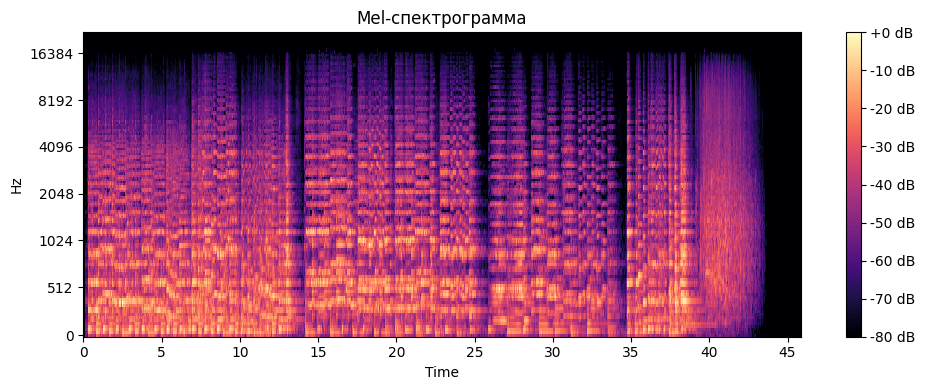

In [30]:
# Параметры для спектрограммы
n_fft = 2048  # размер окна для FFT

hop_length = 512  # шаг между окнами
n_mels = 128  # количество Mel-фильтров
  
# Вычисление Mel-спектрограммы
mel_spec = librosa.feature.melspectrogram(y=signal, sr=sample_rate,
                                          n_fft=n_fft,
                                          hop_length=hop_length,
                                          n_mels=n_mels)

# Преобразование в децибелы
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

# Визуализация
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spec_db, sr=sample_rate,
                         hop_length=hop_length,
                         x_axis='time', y_axis='mel')

plt.colorbar(format='%+2.0f dB')
plt.title('Mel-спектрограмма')
plt.tight_layout()
plt.show()

In [32]:
# Ручной вариант
# вычисление STFT (сглаживание по умолчанию)
stft = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length, win_length=n_fft)

# спектрограмма энергий
power_spec = np.abs(stft)**2

# Mel-фильтры
mel_basis = librosa.filters.mel(sr=sample_rate, n_fft=n_fft, n_mels=n_mels)

# взвешивание энергетического спектра с помощью Mel-фильтров)
mel_spec = np.dot(mel_basis, power_spec)

# переход в децибелы
mel_spec_db_manual = librosa.power_to_db(mel_spec, ref=np.max)

# сравнение спектрограмм
if np.testing.assert_array_equal(mel_spec_db, mel_spec_db_manual):
    print("Успех! Спектрограммы совпали.")

In [33]:
url = "https://raw.githubusercontent.com/librosa/data/main/audio/sorohanro_-_solo-trumpet-06.hq.ogg"
response = requests.get(url, stream=True)

audio_path = BASE_DIR / "data" / "study_notebook" / "Hungarian_Dance_number_5.ogg"
with open(audio_path, "wb") as f:
    f.write(response.content)

[[4.15861286e-05 1.74615678e-04 1.27356208e-04 ... 5.85348630e-16
  2.70707718e-13 3.69796945e-12]
 [3.12273442e-05 2.26538730e-04 8.84624897e-05 ... 4.80937134e-15
  3.69841229e-13 4.37058809e-12]
 [1.55921967e-04 3.64705629e-04 1.46992374e-04 ... 4.56039286e-14
  7.76712787e-13 7.06037138e-12]
 ...
 [4.47474697e-08 1.10644027e-08 1.41467506e-11 ... 2.95126027e-21
  7.71335578e-14 1.30937990e-12]
 [4.41051924e-08 1.09346265e-08 1.34007302e-11 ... 1.49987939e-21
  6.77366827e-14 1.15002105e-12]
 [4.38877343e-08 1.08934746e-08 1.30601302e-11 ... 8.81332468e-22
  6.29016153e-14 1.06806773e-12]]


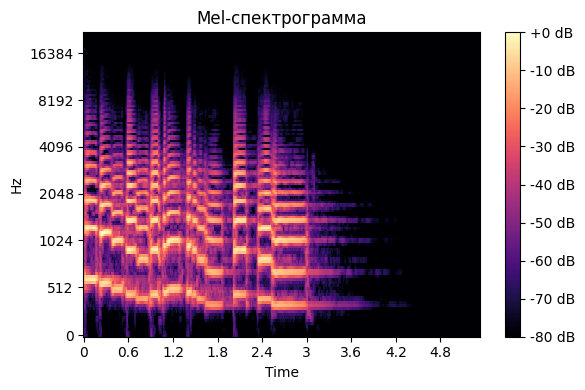

In [34]:
signal, sample_rate = librosa.load(audio_path, sr=None)

# Параметры для спектрограммы
n_fft = 2048  # размер окна для FFT

hop_length = 512  # шаг между окнами
n_mels = 128  # количество Mel-фильтров
  
# Вычисление Mel-спектрограммы
mel_spec = librosa.feature.melspectrogram(y=signal, sr=sample_rate,
                                          n_fft=n_fft,
                                          hop_length=hop_length,
                                          n_mels=n_mels)
print(mel_spec)

# Преобразование в децибелы
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(6, 4))
librosa.display.specshow(mel_spec_db, sr=sample_rate,
            hop_length=hop_length,
            x_axis='time', y_axis='mel')

plt.colorbar(format='%+2.0f dB')
plt.title('Mel-спектрограмма')
plt.tight_layout()
plt.show() 